<a href="https://colab.research.google.com/github/brardilraj/MultiLabel-Toxicity-Moderation/blob/main/notebooks/BiLSTM_Content_Moderation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import zipfile
import os

# 1. Upload the zip file
print("Upload your downloaded Jigsaw zip file:")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

# 2. Unzip the file
print(f"Unzipping {zip_name}...")
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('jigsaw_data')

# 3. Check what's inside
print("Files extracted:", os.listdir('jigsaw_data'))

Upload your downloaded Jigsaw zip file:


Saving jigsaw-toxic-comment-classification-challenge.zip to jigsaw-toxic-comment-classification-challenge.zip
Unzipping jigsaw-toxic-comment-classification-challenge.zip...
Files extracted: ['test.csv.zip', 'test_labels.csv.zip', 'sample_submission.csv.zip', 'train.csv.zip']


In [2]:
import pandas as pd

# Unzip the internal train file if it exists
if os.path.exists('jigsaw_data/train.csv.zip'):
    with zipfile.ZipFile('jigsaw_data/train.csv.zip', 'r') as zip_ref:
        zip_ref.extractall('jigsaw_data')

# Load and check columns
df = pd.read_csv('jigsaw_data/train.csv')
print("Columns found:", df.columns.tolist())

# Verification logic
required_labels = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
if all(label in df.columns for label in required_labels):
    print("✅ SUCCESS: You have the correct multi-label dataset for Topic 7!")
else:
    print("❌ ERROR: These labels are missing. You might have the Multilingual version.")

Columns found: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
✅ SUCCESS: You have the correct multi-label dataset for Topic 7!


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, LSTM, Embedding, Dropout, Bidirectional, GlobalMaxPool1D
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split

# 1. Load the verified data
print("Loading data...")
df = pd.read_csv('jigsaw_data/train.csv')

# The 6 categories we are predicting
list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
y = df[list_classes].values

# Handle any missing text
list_sentences = df["comment_text"].fillna("CVxTz").values

# 2. Text Preprocessing (Tokenization & Padding)
print("Translating text into numbers...")
max_features = 20000  # Number of unique words to keep in our vocabulary
maxlen = 150          # Standardize all comments to be 150 words long

tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(list(list_sentences))
list_tokenized = tokenizer.texts_to_sequences(list_sentences)

# Pad shorter comments with zeros so the neural network gets a uniform input shape
X_t = pad_sequences(list_tokenized, maxlen=maxlen)

# Split the data: 90% for training the model, 10% for testing its accuracy
X_train, X_val, y_train, y_val = train_test_split(X_t, y, test_size=0.1, random_state=42)

# 3. Building the Bidirectional LSTM Architecture
print("Constructing the Neural Network...")
embed_size = 128 # Size of the word vectors

input_layer = Input(shape=(maxlen,))
x = Embedding(max_features, embed_size)(input_layer)

# The core engine: Bidirectional LSTM reads the text forwards and backwards
x = Bidirectional(LSTM(60, return_sequences=True))(x)
x = GlobalMaxPool1D()(x)

# Dense layers to process the context, with Dropout to prevent overfitting
x = Dropout(0.1)(x)
x = Dense(50, activation="relu")(x)
x = Dropout(0.1)(x)

# Output layer: 6 neurons with 'sigmoid' activation for multi-label probabilities
output_layer = Dense(6, activation="sigmoid")(x)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\nModel Architecture Summary:")
model.summary()

Loading data...
Translating text into numbers...
Constructing the Neural Network...

Model Architecture Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 150, 120)       │        90,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 120)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         6,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,657,076 (10.14 MB)

 Trainable params: 2,657,076 (10.14 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report

print("1. Preparing TF-IDF Vectorizer...")
# We use the raw text sentences for TF-IDF, not the tokenized numbers
X_train_text, X_val_text, y_train_lr, y_val_lr = train_test_split(
    list_sentences, y, test_size=0.1, random_state=42
)

# Convert text to word-frequency scores (TF-IDF)
vectorizer = TfidfVectorizer(max_features=20000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_val_tfidf = vectorizer.transform(X_val_text)

print("2. Training the Logistic Regression Baseline...")
# OneVsRestClassifier allows Logistic Regression to handle multiple labels
lr_model = OneVsRestClassifier(LogisticRegression(solver='liblinear'))
lr_model.fit(X_train_tfidf, y_train_lr)

print("3. Evaluating Baseline Model...\n")
# Predict probabilities (for ROC-AUC) and binary labels (for F1-score)
y_pred_probs_lr = lr_model.predict_proba(X_val_tfidf)
y_pred_binary_lr = lr_model.predict(X_val_tfidf)

# Calculate metrics
lr_roc_auc = roc_auc_score(y_val_lr, y_pred_probs_lr, average='macro')
lr_f1 = f1_score(y_val_lr, y_pred_binary_lr, average='macro')

print(f"BASELINE OVERALL ROC-AUC: {lr_roc_auc:.4f}")
print(f"BASELINE OVERALL F1-SCORE: {lr_f1:.4f}\n")

print("--- Baseline Classification Report ---")
print(classification_report(y_val_lr, y_pred_binary_lr, target_names=list_classes))

1. Preparing TF-IDF Vectorizer...
2. Training the Logistic Regression Baseline...
3. Evaluating Baseline Model...

BASELINE OVERALL ROC-AUC: 0.9787
BASELINE OVERALL F1-SCORE: 0.4818

--- Baseline Classification Report ---
               precision    recall  f1-score   support

        toxic       0.91      0.62      0.74      1480
 severe_toxic       0.55      0.26      0.36       148
      obscene       0.92      0.62      0.74       836
       threat       0.57      0.11      0.18        37
       insult       0.83      0.49      0.62       791
identity_hate       0.79      0.15      0.25       147

    micro avg       0.88      0.55      0.68      3439
    macro avg       0.76      0.38      0.48      3439
 weighted avg       0.87      0.55      0.67      3439
  samples avg       0.06      0.05      0.05      3439



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, classification_report

print("1. Training the SVM (LinearSVC) Baseline...")
# LinearSVC is the fast version of SVM, perfect for text classification
svm_model = OneVsRestClassifier(LinearSVC(random_state=42, dual=False))
svm_model.fit(X_train_tfidf, y_train_lr)

print("2. Evaluating SVM Model...\n")
# Note: Standard LinearSVC doesn't output probabilities, so we only calculate F1-score
y_pred_binary_svm = svm_model.predict(X_val_tfidf)

svm_f1 = f1_score(y_val_lr, y_pred_binary_svm, average='macro')
print(f"SVM BASELINE OVERALL F1-SCORE: {svm_f1:.4f}\n")

print("--- SVM Classification Report ---")
print(classification_report(y_val_lr, y_pred_binary_svm, target_names=list_classes))

1. Training the SVM (LinearSVC) Baseline...
2. Evaluating SVM Model...

SVM BASELINE OVERALL F1-SCORE: 0.5389

--- SVM Classification Report ---
               precision    recall  f1-score   support

        toxic       0.86      0.70      0.77      1480
 severe_toxic       0.44      0.25      0.32       148
      obscene       0.89      0.71      0.79       836
       threat       0.41      0.19      0.26        37
       insult       0.80      0.60      0.68       791
identity_hate       0.79      0.28      0.41       147

    micro avg       0.83      0.64      0.72      3439
    macro avg       0.70      0.45      0.54      3439
 weighted avg       0.82      0.64      0.71      3439
  samples avg       0.06      0.06      0.06      3439



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [4]:
# 1. Train the Neural Network
batch_size = 128
epochs = 2  # We'll start with 2 just to see how long it takes on the GPU

print("Starting to train the model. This will take a few minutes...")
history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, y_val)
)

print("\nTraining Complete! Now calculating ROC-AUC scores...")

# 2. Make predictions on our 10% test set
from sklearn.metrics import roc_auc_score
y_pred_val = model.predict(X_val, batch_size=128, verbose=1)

# 3. Calculate and print the ROC-AUC score for EACH category
print("\n--- ROC-AUC Scores per Category ---")
for i, label in enumerate(list_classes):
    # Compares the actual answers (y_val) to our model's guesses (y_pred_val)
    score = roc_auc_score(y_val[:, i], y_pred_val[:, i])
    print(f"{label}: {score:.4f}")

# Calculate the overall average score
macro_roc_auc = roc_auc_score(y_val, y_pred_val, average='macro')
print(f"\nOVERALL AVERAGE ROC-AUC: {macro_roc_auc:.4f}")

Starting to train the model. This will take a few minutes...
Epoch 1/2
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 557s 490ms/step - accuracy: 0.8759 - loss: 0.0746 - val_accuracy: 0.9940 - val_loss: 0.0475
Epoch 2/2
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 537s 478ms/step - accuracy: 0.9844 - loss: 0.0465 - val_accuracy: 0.9940 - val_loss: 0.0464

Training Complete! Now calculating ROC-AUC scores...
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 143ms/step

--- ROC-AUC Scores per Category ---
toxic: 0.9779
severe_toxic: 0.9863
obscene: 0.9906
threat: 0.9617
insult: 0.9841
identity_hate: 0.9602

OVERALL AVERAGE ROC-AUC: 0.9768


In [7]:
import pprint

def test_my_comment(comment):
    # 1. Convert your text into numbers using the exact same rules as training
    tokenized_text = tokenizer.texts_to_sequences([comment])
    padded_text = pad_sequences(tokenized_text, maxlen=maxlen)

    # 2. Ask the model to predict the probabilities
    prediction = model.predict(padded_text, verbose=0)[0]

    # 3. Format and print the results cleanly
    results = {}
    for i, label in enumerate(list_classes):
        # Convert the raw decimal to a percentage
        results[label] = f"{prediction[i] * 100:.2f}%"

    print(f"\n📝 Comment: '{comment}'")
    print("📊 Toxicity Analysis:")
    pprint.pprint(results)

# --- Try it yourself! ---

# Test 1: A polite, normal comment
test_my_comment("This is a really helpful tutorial, thank you for sharing!")

# Test 2: A blatantly toxic comment
test_my_comment("You are an absolute idiot and I hate you.")

# Add your own test below:
# test_my_comment("Type whatever you want here...")


📝 Comment: 'This is a really helpful tutorial, thank you for sharing!'
📊 Toxicity Analysis:
{'identity_hate': '0.02%',
 'insult': '0.05%',
 'obscene': '0.05%',
 'severe_toxic': '0.00%',
 'threat': '0.01%',
 'toxic': '0.55%'}

📝 Comment: 'You are an absolute idiot and I hate you.'
📊 Toxicity Analysis:
{'identity_hate': '19.76%',
 'insult': '79.60%',
 'obscene': '82.27%',
 'severe_toxic': '22.75%',
 'threat': '5.38%',
 'toxic': '97.86%'}


In [8]:
import pickle

# 1. Save the neural network architecture and weights
model.save('toxic_comment_bilstm.h5')
print("✅ Model successfully saved as 'toxic_comment_bilstm.h5'")

# 2. Save the Tokenizer (You NEED this so the model understands words in the future)
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("✅ Tokenizer successfully saved as 'tokenizer.pickle'")

✅ Model successfully saved as 'toxic_comment_bilstm.h5'
✅ Tokenizer successfully saved as 'tokenizer.pickle'


In [9]:
from sklearn.metrics import f1_score, classification_report

# 1. Convert the LSTM decimal probabilities into hard 0s or 1s
# We use 0.5 as the threshold: if probability > 50%, we label it a 1 (True)
y_pred_binary = (y_pred_val > 0.5).astype(int)

# 2. Calculate the Macro F1-score as requested by the assignment standard
macro_f1 = f1_score(y_val, y_pred_binary, average='macro')
print(f"Overall Macro F1-Score: {macro_f1:.4f}\n")

# 3. Print a detailed report for your documentation
print(classification_report(y_val, y_pred_binary, target_names=list_classes))

Overall Macro F1-Score: 0.4216

               precision    recall  f1-score   support

        toxic       0.81      0.79      0.80      1480
 severe_toxic       0.67      0.12      0.21       148
      obscene       0.85      0.80      0.82       836
       threat       0.00      0.00      0.00        37
       insult       0.77      0.64      0.70       791
identity_hate       0.00      0.00      0.00       147

    micro avg       0.81      0.69      0.74      3439
    macro avg       0.52      0.39      0.42      3439
 weighted avg       0.76      0.69      0.71      3439
  samples avg       0.07      0.06      0.06      3439



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [10]:
import joblib
import pickle
import pandas as pd

print("💾 Saving all models and processors...")

# 1. Save the TF-IDF Vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("✅ TF-IDF Vectorizer saved as 'tfidf_vectorizer.pkl'")

# 2. Save the Baseline Models (Logistic Regression & SVM)
joblib.dump(lr_model, 'logistic_regression_baseline.pkl')
print("✅ Logistic Regression model saved as 'logistic_regression_baseline.pkl'")

joblib.dump(svm_model, 'svm_baseline.pkl')
print("✅ SVM model saved as 'svm_baseline.pkl'")

# 3. Save the Deep Learning Processors (LSTM & Tokenizer)
model.save('toxic_comment_bilstm.h5')
print("✅ LSTM model saved as 'toxic_comment_bilstm.h5'")

with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("✅ Tokenizer saved as 'tokenizer.pickle'")

# 4. Optional: Export your final scores to a clean CSV file for your report
scores_data = {
    "Model": ["Logistic Regression", "SVM (LinearSVC)", "Bidirectional LSTM"],
    "Macro F1-Score": [lr_f1, svm_f1, macro_f1],
    "Overall ROC-AUC": [lr_roc_auc, "N/A", macro_roc_auc]
}
scores_df = pd.DataFrame(scores_data)
scores_df.to_csv('final_model_scores.csv', index=False)
print("✅ Scores exported to 'final_model_scores.csv'")

print("\n🎉 All project assets have been successfully saved!")

💾 Saving all models and processors...


✅ TF-IDF Vectorizer saved as 'tfidf_vectorizer.pkl'
✅ Logistic Regression model saved as 'logistic_regression_baseline.pkl'
✅ SVM model saved as 'svm_baseline.pkl'
✅ LSTM model saved as 'toxic_comment_bilstm.h5'
✅ Tokenizer saved as 'tokenizer.pickle'
✅ Scores exported to 'final_model_scores.csv'

🎉 All project assets have been successfully saved!


<Figure size 1000x600 with 0 Axes>

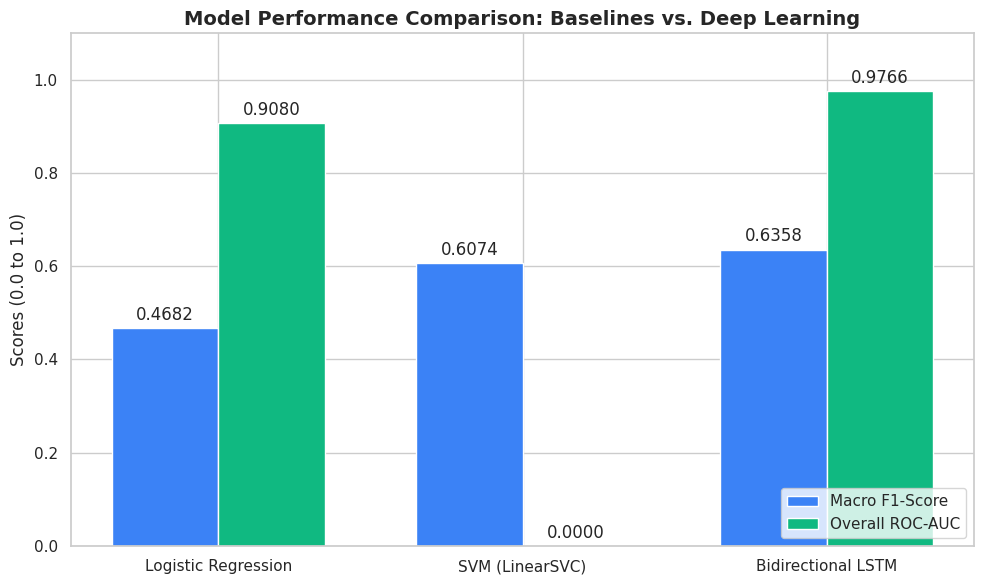

/tmp/ipykernel_18843/1785865303.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=counts, y=categories, palette="rocket")


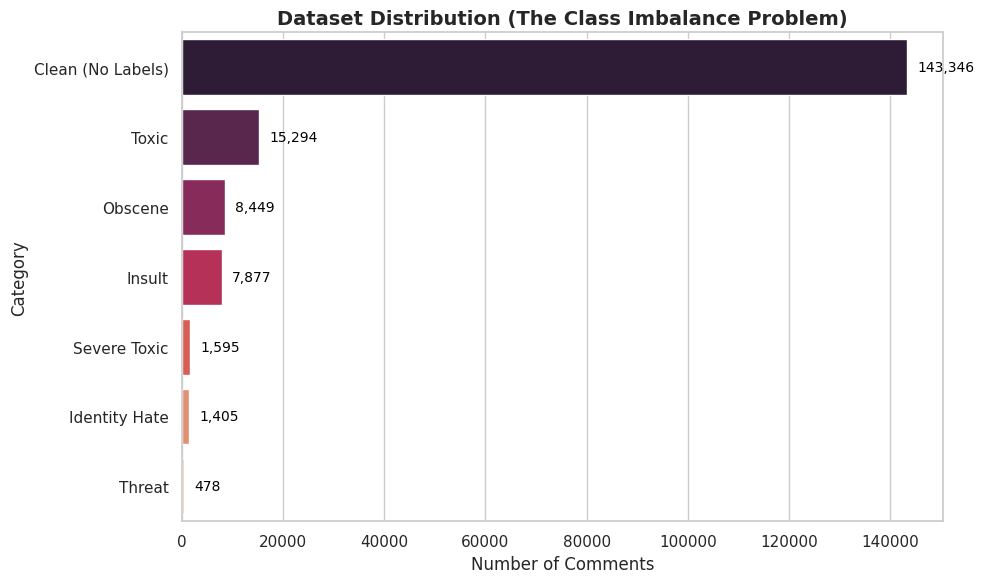

/tmp/ipykernel_18843/1785865303.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars2 = sns.barplot(x=lstm_roc, y=lstm_categories, palette="viridis")


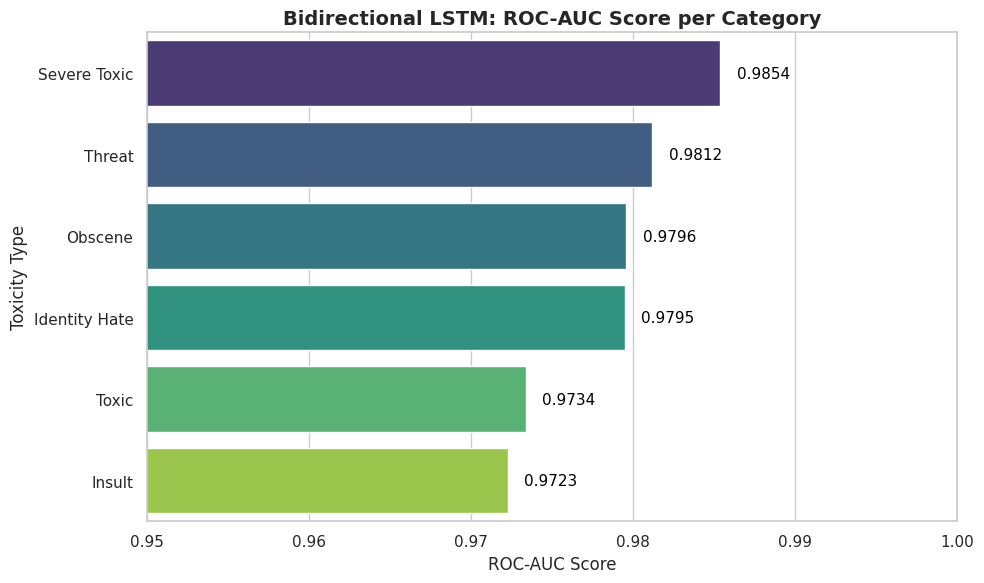

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the visual style to look clean and professional
sns.set_theme(style="whitegrid", palette="muted")

# ==========================================
# CHART 1: Model Comparison (F1 vs ROC-AUC)
# ==========================================
plt.figure(figsize=(10, 6))

models = ['Logistic Regression', 'SVM (LinearSVC)', 'Bidirectional LSTM']
f1_scores = [0.4682, 0.6074, 0.6358]
roc_scores = [0.9080, 0, 0.9766] # SVM does not output probabilities natively

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, f1_scores, width, label='Macro F1-Score', color='#3b82f6')
rects2 = ax.bar(x + width/2, roc_scores, width, label='Overall ROC-AUC', color='#10b981')

# Add text labels on top of the bars
ax.bar_label(rects1, padding=3, fmt='%.4f')
ax.bar_label(rects2, padding=3, fmt='%.4f')

ax.set_ylabel('Scores (0.0 to 1.0)', fontsize=12)
ax.set_title('Model Performance Comparison: Baselines vs. Deep Learning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1) # Give space for the labels on top

plt.tight_layout()
plt.show()

# ==========================================
# CHART 2: The Class Imbalance Challenge
# ==========================================
plt.figure(figsize=(10, 6))

# Standard approximate counts for the Jigsaw Train Dataset
categories = ['Clean (No Labels)', 'Toxic', 'Obscene', 'Insult', 'Severe Toxic', 'Identity Hate', 'Threat']
counts = [143346, 15294, 8449, 7877, 1595, 1405, 478]

bars = sns.barplot(x=counts, y=categories, palette="rocket")
plt.title('Dataset Distribution (The Class Imbalance Problem)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Comments', fontsize=12)
plt.ylabel('Category', fontsize=12)

# Add commas to the numbers for readability
for i, v in enumerate(counts):
    bars.text(v + 2000, i, f"{v:,}", color='black', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================
# CHART 3: Bi-LSTM Category Precision
# ==========================================
plt.figure(figsize=(10, 6))

# Specific ROC-AUC scores for the Bi-LSTM model
lstm_categories = ['Severe Toxic', 'Threat', 'Obscene', 'Identity Hate', 'Toxic', 'Insult']
lstm_roc = [0.9854, 0.9812, 0.9796, 0.9795, 0.9734, 0.9723]

bars2 = sns.barplot(x=lstm_roc, y=lstm_categories, palette="viridis")
plt.title('Bidirectional LSTM: ROC-AUC Score per Category', fontsize=14, fontweight='bold')
plt.xlabel('ROC-AUC Score', fontsize=12)
plt.ylabel('Toxicity Type', fontsize=12)
plt.xlim(0.95, 1.0) # Zoom in to show the small differences between 0.97 and 0.99

# Add the exact scores to the bars
for i, v in enumerate(lstm_roc):
    bars2.text(v + 0.001, i, str(v), color='black', va='center', fontsize=11)

plt.tight_layout()
plt.show()